In [2]:
import torch
import torch.nn.functional as F
from torchvision import transforms
import numpy as np
from collections import Counter
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu
import matplotlib.pyplot as plt
import textwrap

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adityajn105/flickr8k")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Shubh Sareen\.cache\kagglehub\datasets\adityajn105\flickr8k\versions\1


In [4]:
import pandas as pd
df = pd.read_csv(path + '\captions.txt')

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Shubh Sareen\AppData\Local\Temp\ipykernel_30240\2109470830.py:2: SyntaxWarning: invalid escape sequence '\c'
  df = pd.read_csv(path + '\captions.txt')


In [5]:
import re

def tokenize(caption):
    tokens = re.findall(r'\b\w+\b', caption.lower().strip())
    return ['<start>'] + tokens + ['<end>']

df['tokens'] = df['caption'].apply(tokenize)

In [6]:
def load_glove(glovepath):
    embeddings = {}
    with open (glovepath, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.strip().split()
            word = values[0]
            vector = torch.tensor([float(val) for val in values[1:]], dtype=torch.float32)
            embeddings[word] = vector
    return embeddings
glovepath = '../glove.6B.100d.txt/glove.6B.100d.txt'
gloveembedding = load_glove(glovepath)

In [7]:
all_tokens = [token for tokens in df['tokens'] for token in tokens]
counter = Counter(all_tokens)
threashold = 2
words = [word for word, freq in counter.items() if freq >= threashold]

In [8]:
word2idx = {
    '<pad>'  : 0,
    '<start>': 1,
    '<end>'  : 2,
    '<unk>'  : 3, 
}

idx2word = {
    0: '<pad>',
    1: '<start>',
    2: '<end>',
    3: '<unk>',
}

idx = 4
for word in words:
    if word not in word2idx:
        word2idx[word] = idx
        idx2word[idx] = word
        idx += 1

In [9]:
embedding_matrix = np.zeros((len(word2idx), 100))  # for 100d GloVe

for word, idx in word2idx.items():
    if word in gloveembedding:
        embedding_matrix[idx] = gloveembedding[word]
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(100,))

C:\Users\Shubh Sareen\AppData\Local\Temp\ipykernel_30240\649752373.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  embedding_matrix[idx] = gloveembedding[word]


In [10]:
def encode_caption(tokens, word2idx, max_len):
    captions_ids = [word2idx.get(token, word2idx['<unk>']) for token in tokens]
    if len(captions_ids) < max_len:
        captions_ids += [word2idx['<pad>']] * (max_len - len(captions_ids))
    else:
        captions_ids = captions_ids[:max_len]
    return captions_ids    

In [11]:
df['caption_len'] = df['tokens'].apply(len)
df['caption_len'].describe()

count    40455.000000
mean        12.816982
std          3.769411
min          3.000000
25%         10.000000
50%         12.000000
75%         15.000000
max         39.000000
Name: caption_len, dtype: float64

In [12]:
MAX_LEN = 39
df['caption_encoded'] = df['tokens'].apply(lambda x: encode_caption(x, word2idx, MAX_LEN))

In [13]:
transform = transforms.Compose(
    [transforms.Resize((224, 224)), 
     transforms.ToTensor(), 
     transforms.Normalize(
         mean=[0.485, 0.456, 0.406], 
         std=[0.229, 0.224, 0.225]
         )
     ]
    )

In [89]:
from torchvision import models
import torch.nn as nn

resnet = models.resnet50(pretrained=True)
modules = list(resnet.children())[:-1]
resnet = nn.Sequential(*modules)

device = 'cuda' if torch.accelerator.is_available() else 'cpu'

resnet.eval()
resnet.to(device)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [ ]:
class ImageEncoder(nn.Module):
    def __init__(self):
        super(ImageEncoder, self).__init__()
        resnet = models.resnet50(pretrained=True)
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])
        
    def forward(self, images):
        features = self.resnet(images)
        features = features.flatten(2)
        features = features.permute(0, 2, 1)
        return features

In [105]:
class Attention(nn.Module):
    def __init__(self, hidden_dim, feature_dim, attn_dim):
        super(Attention, self).__init__()
        self.attn_feat = nn.Linear(feature_dim, attn_dim)
        self.attn_hidden = nn.Linear(hidden_dim, attn_dim)
        self.attn_score = nn.Linear(attn_dim, 1)
        
    def forward(self, features, hidden):
        attn_feat = self.attn_feat(features)
        attn_hidden = self.attn_hidden(hidden).unsqueeze(1)
        attn = torch.tanh(attn_feat + attn_hidden)
        e = self.attn_score(attn).squeeze(2)
        alpha = F.softmax(e, dim=1)
        context = (features * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

In [106]:
class CaptionDecoder(nn.Module):
    def __init__(self, attention_dim, feature_dim, embed_size, hidden_size, vocab_size, embedding_matrix):
        super(CaptionDecoder, self).__init__()
        self.attention = Attention(hidden_size, feature_dim, attention_dim)
        self.embed = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype=torch.float), freeze=False)
        self.lstm = nn.LSTMCell(embed_size + feature_dim, hidden_size)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.3)
        self.init_h = nn.Linear(feature_dim, hidden_size)
        self.init_c = nn.Linear(feature_dim, hidden_size)
        
    def forward(self, features, captions):
        embeddings = self.embed(captions)
        batch_size = features.size(0)
        seq_length = captions.size(1)

        h = self.init_h(features.mean(dim = 1))
        c = self.init_c(features.mean(dim = 1))
        
        outputs = torch.zeros(batch_size, seq_length, self.linear.out_features).to(features.device)
        
        for t in range(seq_length):
            context, alpha = self.attention(features, h)
            input_lstm = torch.cat([embeddings[:, t, :], context], dim=1)
            h, c = self.lstm(input_lstm, (h, c))
            output = self.linear(self.dropout(h))
            outputs[:, t, :] = output
            
        return outputs

In [107]:
class CaptionDataset(Dataset):
    def __init__(self, dataframe, image_folder, transform=None):
        self.df           = dataframe
        self.image_folder = image_folder
        self.transform    = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_folder, row['image'])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        
        caption = torch.tensor(row['caption_encoded'], dtype=torch.long)
        
        return image, caption

In [108]:
image_folder = os.path.join(path, "Images")
dataset = CaptionDataset(df, image_folder, transform=transform)

In [109]:
batch_size = 128

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

In [110]:
embed_size = 100
attention_dim =256
feature_dim = 2048
hidden_size = 512
vocab_size = len(word2idx)

encoder = ImageEncoder().to(device)
decoder = CaptionDecoder(attention_dim, feature_dim, embed_size, hidden_size, vocab_size, embedding_matrix).to(device)
# Freeze the resnet parameters in encoder
for param in encoder.resnet.parameters():
    param.requires_grad = False

C:\Users\Shubh Sareen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Shubh Sareen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [111]:
criterion = nn.CrossEntropyLoss(ignore_index=word2idx['<pad>'])
params = list(decoder.parameters()) + list(encoder.parameters())
optimizer = torch.optim.Adam(params, lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [112]:
def train(encoder, decoder, images, captions, optimizer, criterion, vocab_size):
    encoder.train()
    decoder.train()
    
    images, captions = images.to(device), captions.to(device)
    
    optimizer.zero_grad()
    
    features = encoder(images)
    
    inputs = captions[:, :-1]
    targets = captions[:, 1:]
    outputs = decoder(features, inputs)
    outputs = outputs[:, :targets.size(1), :]
    loss = criterion(outputs.reshape(-1, vocab_size), targets.reshape(-1))
    loss.backward()
    optimizer.step()
    return loss.item()

In [113]:
def test(encoder, decoder, test_dataloader, criterion):
    encoder.eval()
    decoder.eval()

    total_loss = 0
    with torch.no_grad():
        for i, (images, captions) in enumerate(test_dataloader):
            images = images.to(device)
            captions = captions.to(device)
            
            features = encoder(images)
            inputs = captions[:, :-1]
            targets = captions[:, 1:]
            
            outputs = decoder(features, inputs)
            outputs = outputs[:, :targets.size(1), :]
            loss = criterion(outputs.reshape(-1, vocab_size), targets.reshape(-1))
            
            total_loss += loss.item()
    avg_loss = total_loss / len(test_dataloader)
    perplexity = np.exp(avg_loss)
    print(f"Test Avg Loss: {avg_loss:.4f}, Test Perplexity: {perplexity:.2f}")
    return perplexity

In [114]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=11)

In [115]:
train_dataset = CaptionDataset(train_df, image_folder, transform)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
test_dataset = CaptionDataset(test_df, image_folder, transform)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)  

In [116]:
print(device)

cuda


In [125]:

try:
    load = torch.load('./model_encoder_decoder.pth', map_location=device)
    encoder.load_state_dict(load['encoder'])
    decoder.load_state_dict(load['decoder'])
    optimizer.load_state_dict(load['optimizer'])
    min_perp = test(encoder, decoder, test_dataloader, criterion)
except:
    min_perp = np.inf


In [124]:
num_epochs = 50

strike = 0

for epoch in range(num_epochs):
    encoder.train()
    decoder.train()
    
    train_loss = 0
    total_loss = 0
    
    for i, (images, captions) in enumerate(train_dataloader):
        
        loss = train(encoder, decoder, images, captions, optimizer, criterion, vocab_size)
        train_loss += loss
        """ if i%100 == 0: """
        print(f"Epoch [{epoch + 1} / {num_epochs}, Step[{i}/{len(train_dataloader)}], Loss: {loss:.4f}]")
        """ print(f"Epoch {epoch+1}, Avg Loss:{total_loss/len(train_dataloader):.4f}") """
    avg_loss = train_loss / len(train_dataloader)
    perplexity = np.exp(avg_loss)
    test_perp = test(encoder, decoder, test_dataloader, criterion)
    if min_perp > test_perp:
        strike = 0
        min_perp = test_perp
        torch.save({
            'encoder': encoder.state_dict(),
            'decoder': decoder.state_dict(),
            'optimizer': optimizer.state_dict()
        }, f"model_encoder_decoder.pth")
        print("Saving model...")
    else:
        strike += 1
    
    if strike > 4:
        break
    print(perplexity)
    scheduler.step(avg_loss)

Epoch [1 / 50, Step[0/253], Loss: 3.3024]
Epoch [1 / 50, Step[1/253], Loss: 3.3161]
Epoch [1 / 50, Step[2/253], Loss: 3.4403]
Epoch [1 / 50, Step[3/253], Loss: 3.3073]
Epoch [1 / 50, Step[4/253], Loss: 3.3498]
Epoch [1 / 50, Step[5/253], Loss: 3.3109]
Epoch [1 / 50, Step[6/253], Loss: 3.2879]
Epoch [1 / 50, Step[7/253], Loss: 3.4603]
Epoch [1 / 50, Step[8/253], Loss: 3.2701]
Epoch [1 / 50, Step[9/253], Loss: 3.4442]
Epoch [1 / 50, Step[10/253], Loss: 3.4632]
Epoch [1 / 50, Step[11/253], Loss: 3.4301]
Epoch [1 / 50, Step[12/253], Loss: 3.4858]
Epoch [1 / 50, Step[13/253], Loss: 3.4238]
Epoch [1 / 50, Step[14/253], Loss: 3.5693]
Epoch [1 / 50, Step[15/253], Loss: 3.5355]
Epoch [1 / 50, Step[16/253], Loss: 3.5504]
Epoch [1 / 50, Step[17/253], Loss: 3.3963]
Epoch [1 / 50, Step[18/253], Loss: 3.2831]
Epoch [1 / 50, Step[19/253], Loss: 3.5429]
Epoch [1 / 50, Step[20/253], Loss: 3.4198]
Epoch [1 / 50, Step[21/253], Loss: 3.4582]
Epoch [1 / 50, Step[22/253], Loss: 3.4639]
Epoch [1 / 50, Step[2

In [127]:
def GenerateCaption(encoder, decoder, image_tensor, word2idx, idx2word, max_len=38):
    encoder.eval()
    decoder.eval()
    
    with torch.no_grad():
        features = encoder(image_tensor)
        caption = [word2idx['<start>']]
        
        for _ in range(max_len):
            input_tensor = torch.tensor(caption).unsqueeze(0).to(device)
            output = decoder(features, input_tensor)
            predicted_id = output[0, -1].argmax().item()
            
            if idx2word[predicted_id] == '<end>':
                break
            caption.append(predicted_id)
        
        words = [idx2word[idx] for idx in caption[1:]]
        return ' '.join(words)

In [128]:
from PIL import Image

def load_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image)
    if image.dim() == 3:
        image = image.unsqueeze(0)  # Add batch dimension if missing
    return image.to(device)

image_tensor = load_image('./test-images/testimg1.jpg')
print(image_tensor.shape)
if image_tensor.dim() == 3:
    image_tensor = image_tensor.unsqueeze(0)
elif image_tensor.dim() == 4 and image_tensor.shape[0] != 1:
    image_tensor = image_tensor[:1]

# Now call GenerateCaption
caption = GenerateCaption(encoder, decoder, image_tensor, word2idx, idx2word)
print("Generated caption:", caption)

torch.Size([1, 3, 224, 224])
Generated caption: a man in a blue shirt is jumping on a colorful slide


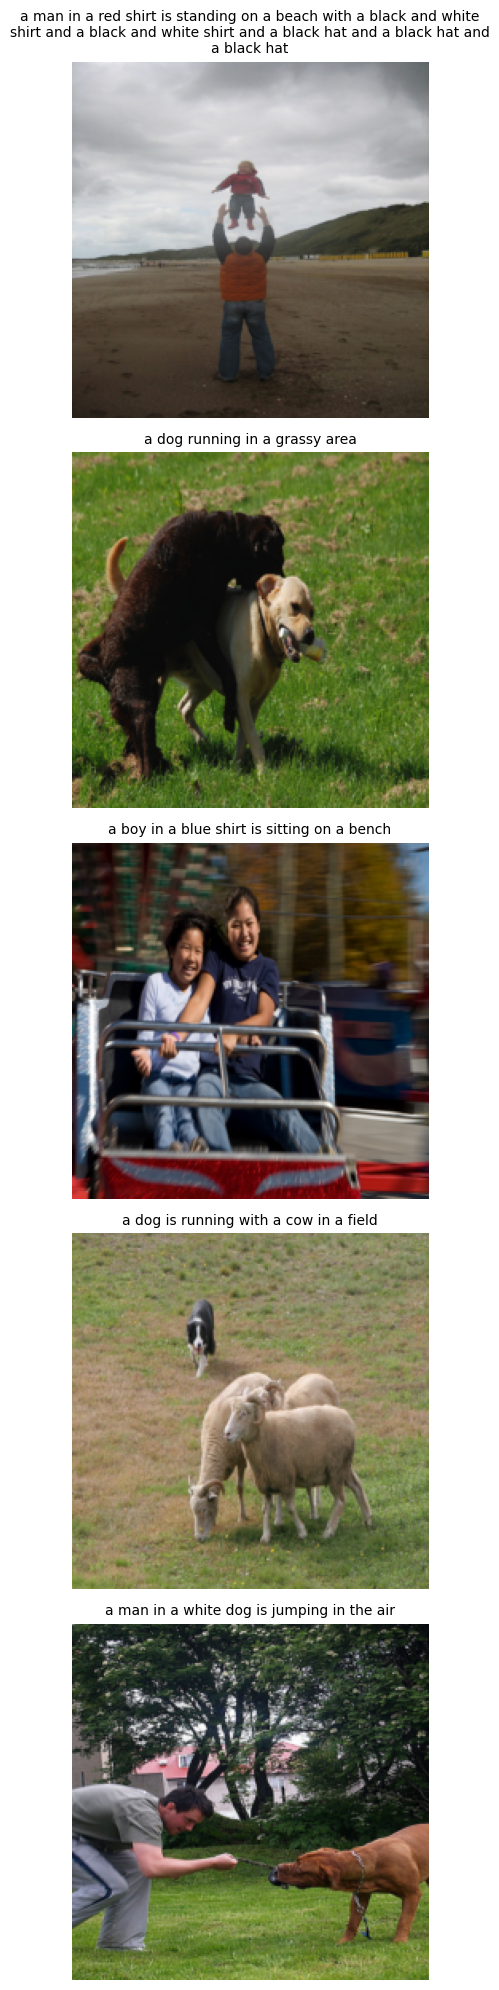

In [129]:
def visualise( df, num_samples = 5):
    fig, axes = plt.subplots(num_samples, 1, figsize=(5, 20))
    for i in range(num_samples):
        image_path = os.path.join(image_folder, df['image'].iloc[i])
        image_tensor = load_image(image_path)
        caption = GenerateCaption(encoder, decoder, image_tensor, word2idx, idx2word)
        wrapped_caption = "\n".join(textwrap.wrap(caption, width=70))
        image_np = image_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
        image_np = image_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        image_np = np.clip(image_np, 0, 1)
        axes[i].imshow(image_np)
        axes[i].set_title(wrapped_caption, fontsize=10)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
visualise(test_df)

In [130]:
references = []
hypotheses = []

for idx, row in test_df.iterrows():
    image_path = os.path.join(image_folder, row['image'])
    gen_caption = GenerateCaption(encoder, decoder, load_image(image_path), word2idx, idx2word)
    gen_tokens = gen_caption.split()
    ref_tokens = [token for token in row['tokens'] if token not in ['<start>', '<end>']]
    references.append([ref_tokens])
    hypotheses.append(gen_tokens)

bleu = corpus_bleu(references, hypotheses)
print(f"BLEU score: {bleu:.4f}")

BLEU score: 0.0632
